# Part 1.1: Data Exploration & ETL Pipeline (AAPL) with Polars

This notebook explores the SimFin bulk data and builds an ETL pipeline for a single company (AAPL) **using Polars** (since it has better optimization & performance than Pandas).

**Steps:**
1. Load raw CSVs and convert to Parquet (one-time, for faster future reads)
2. Load Parquet and filter for AAPL
3. Clean and handle missing values
4. Engineer features (returns, moving averages, lag features)
5. Create the target variable (next-day price movement)
6. Output a clean DataFrame ready for ML

In [81]:
import polars as pl
import matplotlib.pyplot as plt

DATA_DIR = "../data"
TICKER = "AAPL"

## Step 1: Load Raw CSVs and Convert to Parquet

We read the semicolon-delimited CSVs once and save them as Parquet files. All subsequent steps will read from Parquet, which is significantly faster with Polars.

In [82]:
# Read CSVs
companies = pl.read_csv(f"{DATA_DIR}/us-companies.csv", separator=";")
prices = pl.read_csv(f"{DATA_DIR}/us-shareprices-daily.csv", separator=";")

# Save as Parquet for faster future reads
companies.write_parquet(f"{DATA_DIR}/us-companies.parquet")
prices.write_parquet(f"{DATA_DIR}/us-shareprices-daily.parquet")

print(f"Companies: {companies.shape}")
print(f"Prices: {prices.shape}")

Companies: (6532, 11)
Prices: (6210533, 11)


## Step 2: Load Parquet, Filter for AAPL, and Explore

In [83]:
# Load from Parquet
prices = pl.read_parquet(f"{DATA_DIR}/us-shareprices-daily.parquet")

# Filter for AAPL
aapl = prices.filter(pl.col("Ticker") == TICKER)
print(f"AAPL rows: {aapl.shape[0]}, columns: {aapl.shape[1]}")
aapl.head()

AAPL rows: 1238, columns: 11


Ticker,SimFinId,Date,Open,High,Low,Close,Adj. Close,Volume,Dividend,Shares Outstanding
str,i64,str,f64,f64,f64,f64,f64,i64,f64,i64
"""AAPL""",111052,"""2020-04-20""",69.49,70.42,69.21,69.23,66.92,130015000,null,17337340000
"""AAPL""",111052,"""2020-04-21""",69.07,69.31,66.36,67.09,64.85,180991572,null,17337340000
"""AAPL""",111052,"""2020-04-22""",68.4,69.47,68.05,69.03,66.72,117057368,null,17337340000
"""AAPL""",111052,"""2020-04-23""",68.97,70.44,68.72,68.76,66.46,124814328,null,17337340000
"""AAPL""",111052,"""2020-04-24""",69.3,70.75,69.25,70.74,68.38,126508732,null,17337340000


In [84]:
# Check data types and nulls
aapl.describe()

statistic,Ticker,SimFinId,Date,Open,High,Low,Close,Adj. Close,Volume,Dividend,Shares Outstanding
str,str,f64,str,f64,f64,f64,f64,f64,f64,f64,f64
"""count""","""1238""",1238.0,"""1238""",1238.0,1238.0,1238.0,1238.0,1238.0,1238.0,20.0,1238.0
"""null_count""","""0""",0.0,"""0""",0.0,0.0,0.0,0.0,0.0,0.0,1218.0,0.0
"""mean""",null,111052.0,null,162.279289,164.057512,160.612722,162.423514,159.90248,8.2839e7,0.228,1.6141e10
"""std""",null,0.0,null,39.376439,39.616527,39.163711,39.434148,39.961792,4.2737e7,0.017652,6.7537e8
"""min""","""AAPL""",111052.0,"""2020-04-20""",68.4,69.31,66.36,67.09,64.85,2.3234705e7,0.2,1.5022e10
"""25%""",null,111052.0,null,135.02,136.81,133.61,134.99,131.88,5.3477869e7,0.22,1.5698e10
"""50%""",null,111052.0,null,159.94,162.3,157.81,160.01,156.85,7.2348055e7,0.23,1.6030e10
"""75%""",null,111052.0,null,184.41,186.21,182.73,184.8,182.72,9.8322008e7,0.24,1.6688e10
"""max""","""AAPL""",111052.0,"""2025-03-21""",258.19,260.1,257.63,259.02,257.63,3.74295468e8,0.25,1.7337e10


In [85]:
# Check for null values per column
aapl.null_count()

Ticker,SimFinId,Date,Open,High,Low,Close,Adj. Close,Volume,Dividend,Shares Outstanding
u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32
0,0,0,0,0,0,0,0,0,1218,0


In [86]:
# Date range
print(f"Date range: {aapl['Date'].min()} to {aapl['Date'].max()}")

Date range: 2020-04-20 to 2025-03-21


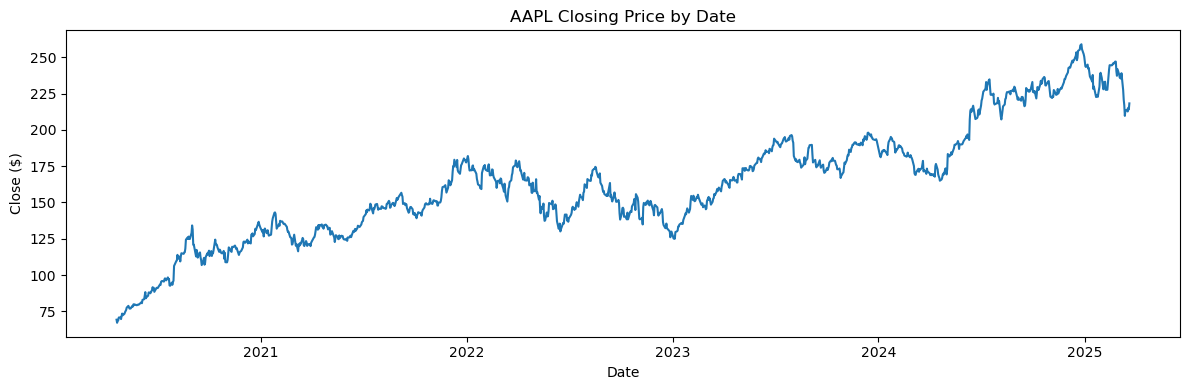

In [87]:
# Plot closing price over time
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(aapl["Date"].cast(pl.Date), aapl["Close"])
ax.set_title(f"{TICKER} Closing Price by Date")
ax.set_xlabel("Date")
ax.set_ylabel("Close ($)")
plt.tight_layout()
plt.show()

## Step 3: Clean Data and Handle Missing Values

From Step 2 we observed:
- `Date` is a string → we need to cast it to `date`
- `Dividend` has 1218 nulls out of 1238 rows → we fill it with 0 (no dividend on most days)
- Drop columns not needed for ML (e.g. `SimFinId`)

In [88]:
# Cast Date, fill Dividend nulls, drop columns not needed for ML
aapl_clean = (
    aapl
    .with_columns(
        pl.col("Date").str.to_date("%Y-%m-%d"),
        pl.col("Dividend").fill_null(0.0),
    )
    .drop("SimFinId", "Ticker")
    .sort("Date")
)

# Use Adj. Close (accounts for stock splits & dividends) - better for ML
# Drop raw Close to avoid data leakage between the two
aapl_clean = aapl_clean.drop("Close").rename({"Adj. Close": "Close"})

print(f"Shape: {aapl_clean.shape}")
print(f"Nulls remaining:")
aapl_clean.null_count()

Shape: (1238, 8)
Nulls remaining:


Date,Open,High,Low,Close,Volume,Dividend,Shares Outstanding
u32,u32,u32,u32,u32,u32,u32,u32
0,0,0,0,0,0,0,0


## Step 4: Feature Engineering

Create features that capture price trends and momentum for the ML model:
- **Daily return**: percentage change in closing price
- **Moving averages** (5-day, 20-day): short and medium-term trends
- **Volatility** (20-day rolling std): measure of price uncertainty
- **Lag features**: previous days' returns give the model recent history

In [89]:
aapl_features = aapl_clean.with_columns([
    # Daily return (% change)
    (pl.col("Close").pct_change()).alias("daily_return"),

    # Moving averages
    pl.col("Close").rolling_mean(window_size=5).alias("ma_5"),
    pl.col("Close").rolling_mean(window_size=20).alias("ma_20"),

    # Volatility (20-day rolling std of returns)
    pl.col("Close").pct_change().rolling_std(window_size=20).alias("volatility_20"),

    # Lag features (previous 1, 2, 3 day returns)
    (pl.col("Close").pct_change()).shift(1).alias("return_lag_1"),
    (pl.col("Close").pct_change()).shift(2).alias("return_lag_2"),
    (pl.col("Close").pct_change()).shift(3).alias("return_lag_3"),
])

print(f"Shape after features: {aapl_features.shape}")
aapl_features.head(25)

Shape after features: (1238, 15)


Date,Open,High,Low,Close,Volume,Dividend,Shares Outstanding,daily_return,ma_5,ma_20,volatility_20,return_lag_1,return_lag_2,return_lag_3
date,f64,f64,f64,f64,i64,f64,i64,f64,f64,f64,f64,f64,f64,f64
2020-04-20,69.49,70.42,69.21,66.92,130015000,0.0,17337340000,null,null,null,null,null,null,null
2020-04-21,69.07,69.31,66.36,64.85,180991572,0.0,17337340000,-0.030932,null,null,null,null,null,null
2020-04-22,68.4,69.47,68.05,66.72,117057368,0.0,17337340000,0.028836,null,null,null,-0.030932,null,null
2020-04-23,68.97,70.44,68.72,66.46,124814328,0.0,17337340000,-0.003897,null,null,null,0.028836,-0.030932,null
2020-04-24,69.3,70.75,69.25,68.38,126508732,0.0,17337340000,0.02889,66.666,null,null,-0.003897,0.028836,-0.030932
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
2020-05-18,78.29,79.12,77.58,76.31,135372500,0.0,17337340000,0.023471,75.172,71.433,0.017961,-0.005867,0.006171,-0.012061
2020-05-19,78.76,79.63,78.25,75.87,101729540,0.0,17337340000,-0.005766,75.256,71.984,0.015952,0.023471,-0.005867,0.006171
2020-05-20,79.17,79.88,79.13,77.35,111504860,0.0,17337340000,0.019507,75.818,72.5155,0.015438,-0.005766,0.023471,-0.005867


In [90]:
# Drop rows with nulls introduced by rolling windows and lags (first ~20 rows)
aapl_features = aapl_features.drop_nulls()
print(f"Shape after dropping nulls: {aapl_features.shape}")
aapl_features.null_count()

Shape after dropping nulls: (1218, 15)


Date,Open,High,Low,Close,Volume,Dividend,Shares Outstanding,daily_return,ma_5,ma_20,volatility_20,return_lag_1,return_lag_2,return_lag_3
u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32
0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


### Normalization (Min-Max Scaling)

We normalize all numeric columns to a 0-1 range. This is important for two reasons:

1. **Model performance**: Logistic Regression is sensitive to feature scales. Without normalization, features like Volume (in the millions) would dominate over daily_return (small decimals), causing the model to underweight important signals.

2. **Feature comparison**: After normalization, the model coefficients become directly comparable, allowing us to interpret which features have the most influence on predictions.

In [ ]:
# Normalize all numeric columns using min-max scaling
numeric_cols = [c for c in aapl_features.columns if aapl_features[c].dtype in [pl.Float64, pl.Int64]]

aapl_normalized = aapl_features.with_columns([
    ((pl.col(c) - pl.col(c).min()) / (pl.col(c).max() - pl.col(c).min())).alias(c)
    for c in numeric_cols
])

aapl_normalized.head()

## Step 5: Create Target Variable

The target is a binary label: did the closing price go **up** (1) or **down** (0) the next day? This is a simple classification problem as recommended by the assignment instructions.

In [92]:
# Target: 1 if next day's close is higher than today's, 0 otherwise
aapl_final = aapl_normalized.with_columns(
    (pl.col("Close").shift(-1) > pl.col("Close")).cast(pl.Int8).alias("target")
)

# Drop the last row (no next-day data available for it)
aapl_final = aapl_final.drop_nulls(subset=["target"])

print(f"Final shape: {aapl_final.shape}")
print(f"\nTarget distribution:")
aapl_final["target"].value_counts()

Final shape: (1217, 16)

Target distribution:


target,count
i8,u32
0,570
1,647


## Step 6: Output Clean DataFrame for ML

Save the final dataset as a Parquet file that will be used by the ML training script.

In [93]:
output_path = f"{DATA_DIR}/aapl_ml_ready.parquet"
aapl_final.write_parquet(output_path)
print(f"Saved to {output_path}")
print(f"Shape: {aapl_final.shape}")
print(f"Columns: {aapl_final.columns}")

Saved to ../data/aapl_ml_ready.parquet
Shape: (1217, 16)
Columns: ['Date', 'Open', 'High', 'Low', 'Close', 'Volume', 'Dividend', 'Shares Outstanding', 'daily_return', 'ma_5', 'ma_20', 'volatility_20', 'return_lag_1', 'return_lag_2', 'return_lag_3', 'target']
